In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kavindurandil/market/Market.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully")

Libraries imported successfully


In [7]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/kavindurandil/market/Market.csv


In [12]:
import pandas as pd

df = pd.read_csv(r'/kaggle/input/datasets/kavindurandil/market/Market.csv')

df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,12/31/1965,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1/3/1966,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1/4/1966,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1/5/1966,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1/6/1966,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [13]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (112457, 8)

Columns:
['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data Types:
Index         object
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
dtype: object

Missing Values:
Index           0
Date            0
Open         2204
High         2205
Low          2206
Close        2207
Adj Close    2213
Volume       2204
dtype: int64

Duplicate Rows:
0


In [15]:
print(df.columns.tolist())

['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [23]:
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.iloc[:-1]
X = df[
    [
        'Open',
        'High',
        'Low',
        'Close',
        'Adj Close',
        'Volume'
    ]
]

y = df['Target']
print(X.head())
print(y.head())
print(df.columns.tolist())

         Open        High         Low       Close   Adj Close  Volume
0  528.690002  528.690002  528.690002  528.690002  528.690002     0.0
1  527.210022  527.210022  527.210022  527.210022  527.210022     0.0
2  527.840027  527.840027  527.840027  527.840027  527.840027     0.0
3  531.119995  531.119995  531.119995  531.119995  531.119995     0.0
4  532.070007  532.070007  532.070007  532.070007  532.070007     0.0
0    0
1    1
2    1
3    1
4    1
Name: Target, dtype: int64
['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Target']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (89964, 6)
Testing data: (22492, 6)


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

scaler.fit_transform(X_train)

scaler.transform(X_test)

array([[ 0.59888917,  0.63506886,  0.60095363,  0.60939984,  0.60936856,
         0.49179363],
       [ 0.16022487,  0.15819333,  0.15267022,  0.1550495 ,  0.15502547,
        -0.2802648 ],
       [-0.68389637, -0.68373635, -0.68369975, -0.6845132 , -0.68452382,
        -0.29478511],
       ...,
       [-0.49214342, -0.49340995, -0.48999973, -0.49125493, -0.49217888,
        -0.28997339],
       [ 0.91296764,  0.93128385,  0.89173895,  0.88342866,  0.88339301,
        -0.29478818],
       [-0.55450716, -0.55621025, -0.55239155, -0.55440412, -0.55441682,
        -0.29478818]])

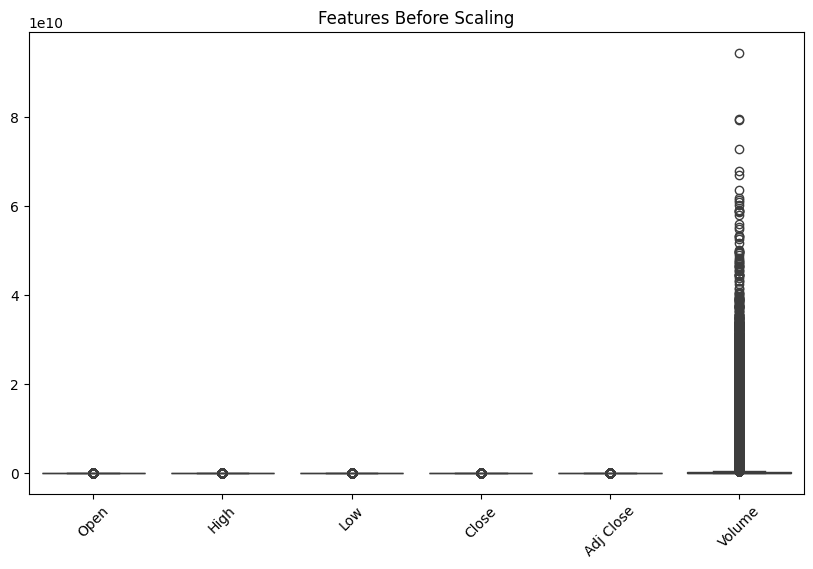

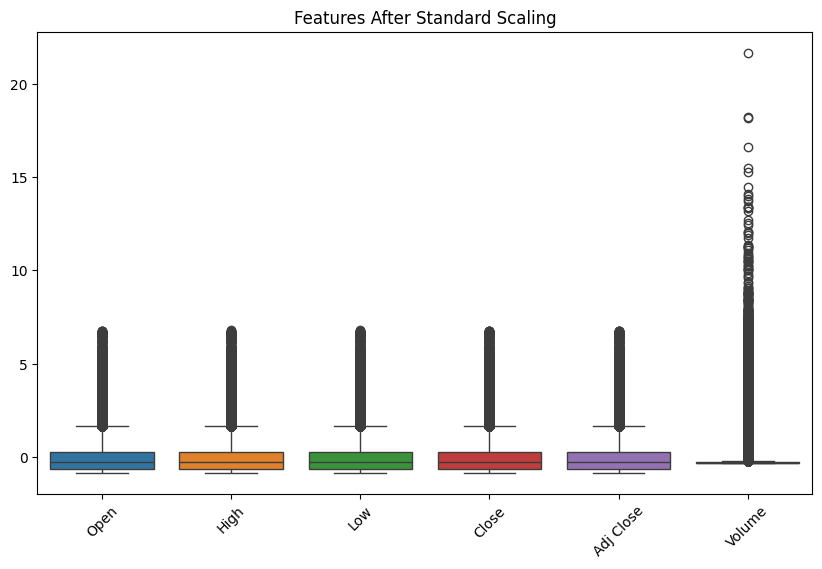

In [31]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=X_train)

plt.title("Features Before Scaling")
plt.xticks(rotation=45)
plt.show()

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

plt.figure(figsize=(10, 6))

sns.boxplot(data=X_train_scaled_df)

plt.title("Features After Standard Scaling")
plt.xticks(rotation=45)
plt.show()



In [32]:
print("Means after scaling:")
print(X_train_scaled_df.mean())

print("\nStandard deviations after scaling:")
print(X_train_scaled_df.std())

Means after scaling:
Open         3.121901e-16
High        -5.310677e-17
Low         -8.606778e-17
Close       -6.793553e-17
Adj Close   -2.530572e-17
Volume       1.627837e-17
dtype: float64

Standard deviations after scaling:
Open         1.000006
High         1.000006
Low          1.000006
Close        1.000006
Adj Close    1.000006
Volume       1.000006
dtype: float64


In [41]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy)

print("KNN Accuracy: {:.2f}%".format(accuracy * 100))



KNN Accuracy: 0.5126711719722568
KNN Accuracy: 51.27%


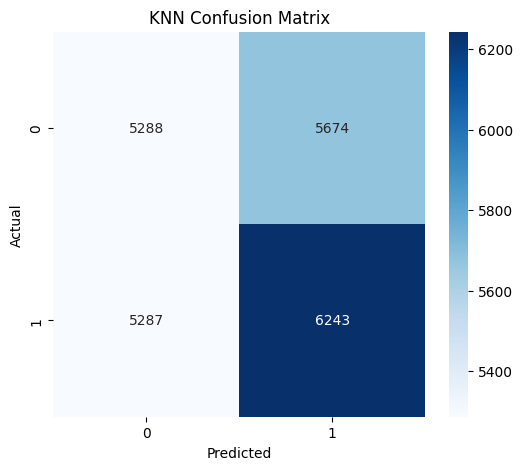

              precision    recall  f1-score   support

           0       0.50      0.48      0.49     10962
           1       0.52      0.54      0.53     11530

    accuracy                           0.51     22492
   macro avg       0.51      0.51      0.51     22492
weighted avg       0.51      0.51      0.51     22492



In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

print(classification_report(y_test, y_pred))



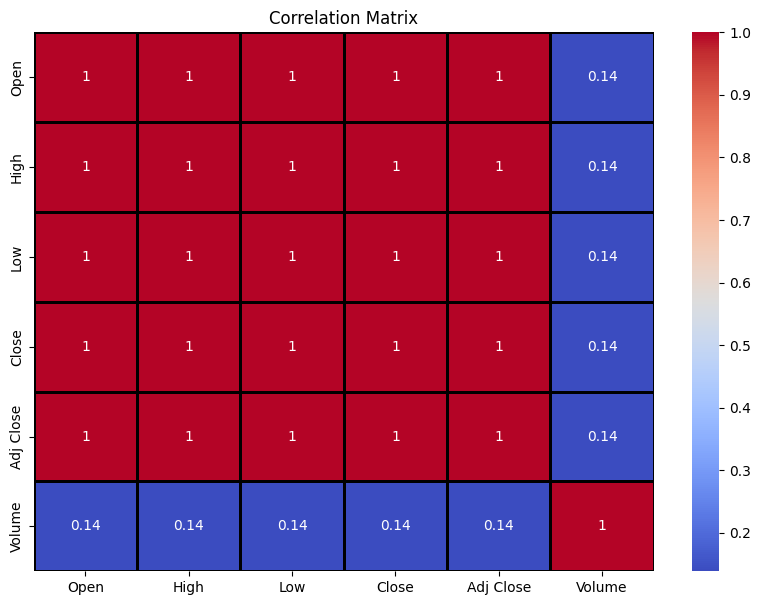

In [43]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=1,
    linecolor='black'
)

plt.title('Correlation Matrix')
plt.show()